Delivery and Logistics Optimization

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [3]:
df=pd.read_csv('order_data.csv')
df.head()

,OrderID,Region,Latitude,Longitude,OrderDate,Price(INR),Weight(kg),Size,Timestamp,Pincode
0,ORD-1001,Hazratganj,26.84821,80.94372,2024-03-15,1250,2.3,Medium,2024-03-15T09:23:45,226001
1,ORD-1002,Alambagh,26.81203,80.91745,2024-07-22,890,0.8,Small,2024-07-22T14:10:32,226005
2,ORD-1003,Gomti Nagar,26.86412,80.99541,2024-01-08,3200,15.5,XL,2024-01-08T11:45:10,226010
3,ORD-1004,Indira Nagar,26.88102,80.99312,2024-05-17,450,1.2,Small,2024-05-17T16:30:55,226016
4,ORD-1005,Aliganj,26.89234,80.96018,2024-09-04,2100,8.7,Large,2024-09-04T08:15:22,226024


In [4]:
df.shape

(100, 10)

In [5]:
df.columns

Index(['OrderID', 'Region', 'Latitude', 'Longitude', 'OrderDate', 'Price(INR)',
       'Weight(kg)', 'Size', 'Timestamp', 'Pincode'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   OrderID     100 non-null    str    
 1   Region      100 non-null    str    
 2   Latitude    100 non-null    float64
 3   Longitude   100 non-null    float64
 4   OrderDate   100 non-null    str    
 5   Price(INR)  100 non-null    int64  
 6   Weight(kg)  100 non-null    float64
 7   Size        100 non-null    str    
 8   Timestamp   100 non-null    str    
 9   Pincode     100 non-null    int64  
dtypes: float64(3), int64(2), str(5)
memory usage: 7.9 KB


In [7]:
df.describe()

,Latitude,Longitude,Price(INR),Weight(kg),Pincode
count,100.000000,100.000000,100.000000,100.000000,100.000000
mean,26.861406,80.960883,1456.900000,6.354000,226014.640000
std,0.026676,0.043103,881.018344,5.161129,9.400752
min,26.803120,80.890340,260.000000,0.400000,226001.000000
25%,26.848892,80.923338,715.000000,2.300000,226005.000000
50%,26.864620,80.958620,1305.000000,4.750000,226016.000000
75%,26.878963,80.992370,2085.000000,9.275000,226022.000000
max,26.910230,81.058120,3420.000000,19.800000,226029.000000


In [8]:
# detcting puyliers if any
numColumns= df.select_dtypes(include=['int64','float64']).columns
print(numColumns)

Index(['Latitude', 'Longitude', 'Price(INR)', 'Weight(kg)', 'Pincode'], dtype='str')


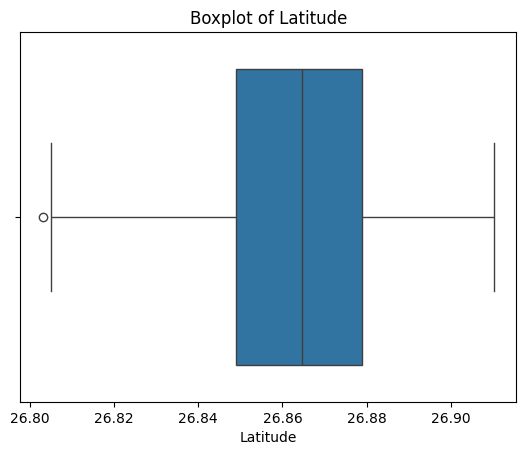

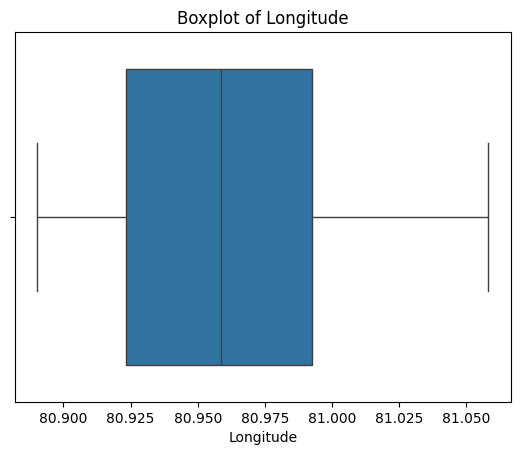

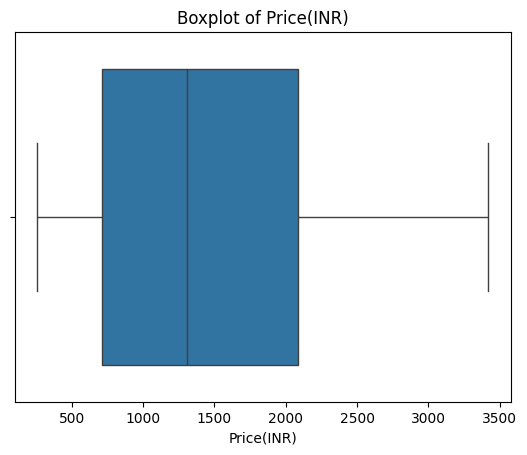

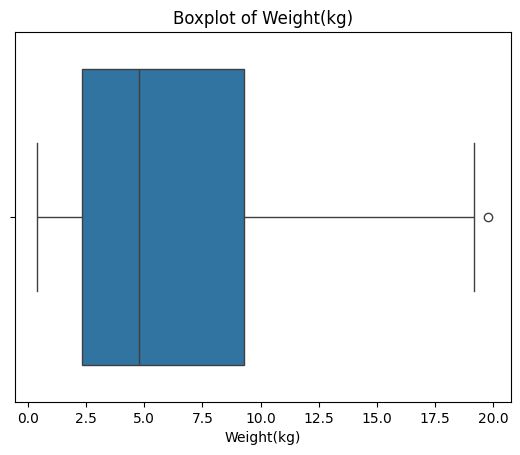

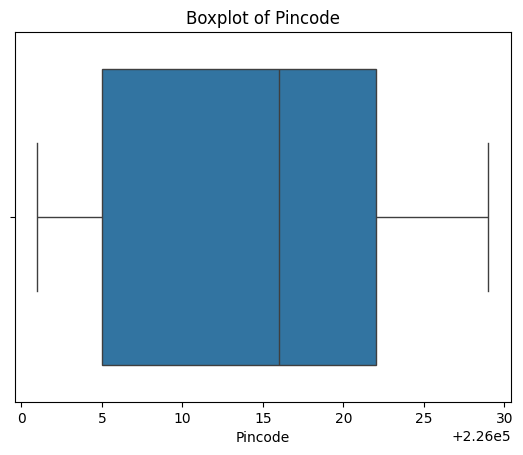

In [9]:
for col in numColumns:
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [10]:
# detecting outliers from IQR method
outliers_summary = {}
for col in numColumns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outliers_summary[col] = {
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'num_outliers': len(outliers),
        'outliers': outliers
    }
    print(f"{col}: Lower Bound = {lower_bound}, Upper Bound = {upper_bound}, Number of Outliers = {len(outliers)}")

Latitude: Lower Bound = 26.803787499999995, Upper Bound = 26.924067500000003, Number of Outliers = 1
Longitude: Lower Bound = 80.81978875000001, Upper Bound = 81.09591874999998, Number of Outliers = 0
Price(INR): Lower Bound = -1340.0, Upper Bound = 4140.0, Number of Outliers = 0
Weight(kg): Lower Bound = -8.162499999999998, Upper Bound = 19.737499999999997, Number of Outliers = 1
Pincode: Lower Bound = 225979.5, Upper Bound = 226047.5, Number of Outliers = 0


In [11]:
# K Menas starts

In [16]:
#Standardization
from sklearn.preprocessing import StandardScaler
X = df[['Latitude', 'Longitude']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [20]:
type(X_scaled)

numpy.ndarray

In [22]:
X_scaled[:5]

array([[-0.49716404, -0.40019363],
       [-1.86024822, -1.01274085],
       [ 0.10224638,  0.80508104],
       [ 0.73895513,  0.75168428],
       [ 1.16543697, -0.01638978]])

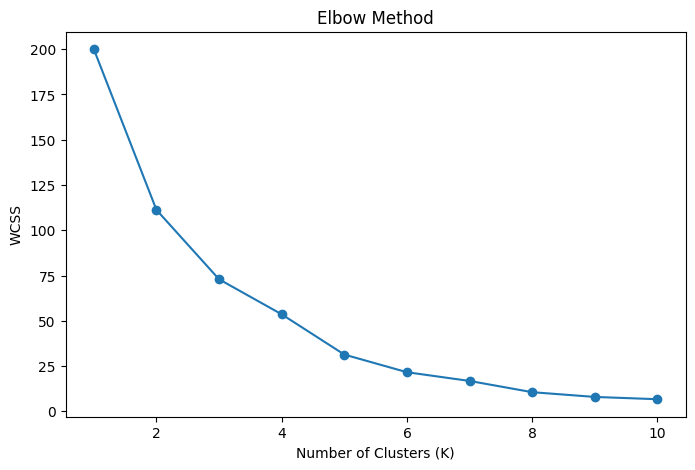

In [24]:
# using elbow method of finding natural cluters
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method')

plt.show()

Naturally the cluster is K=3 as the L is turning at 3 ...
Also according to the data I have 3 warehouses around the city , that also implies K=3

In [25]:
#finally tuning K Means model
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

df['Cluster'] = kmeans.fit_predict(X_scaled)

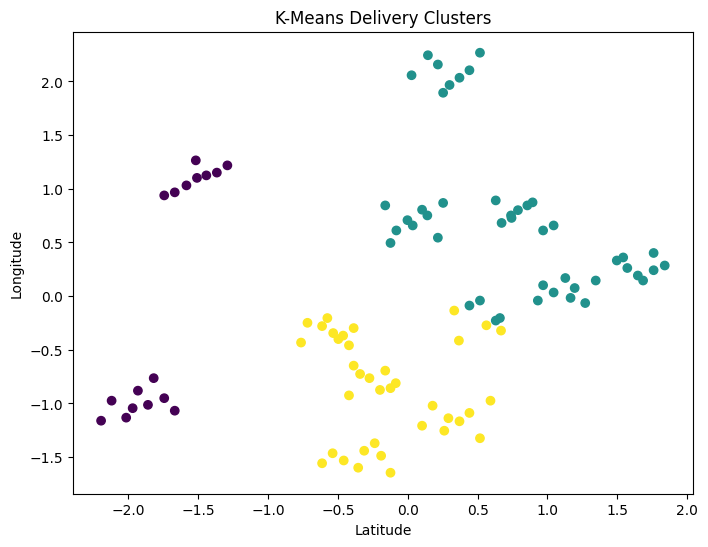

In [ ]:
# plotting the clusters
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=df['Cluster'],
    cmap='viridis'
)

plt.title("K-Means Delivery Clusters")

plt.xlabel("Latitude")
plt.ylabel("Longitude")

plt.show()

In [31]:
kmeans.cluster_centers_

array([[-1.73248539, -0.01109536],
       [ 0.75155171,  0.69388762],
       [-0.13835478, -0.85757323]])

In [ ]:
# real coordinate of centroids of the clusters
centers_real = scaler.inverse_transform(kmeans.cluster_centers_)
print(centers_real)

[[26.81542118 80.96040706]
 [26.88135435 80.9906413 ]
 [26.85773378 80.92410459]]


In [ ]:
# mean coordinates of each clusters
df.groupby('Cluster')[['Latitude', 'Longitude']].mean()

,Latitude,Longitude
Cluster,,
0,26.815421,80.960407
1,26.881354,80.990641
2,26.857734,80.924105


Deciding which warehouse to use

In [35]:
warehouse_locations = pd.read_csv('warehouse_data.csv')
warehouse_locations.head()

,WarehouseID,Name,Zone,Latitude,Longitude,Pincode,AreaSqFt,CapacityUnits,OperatingHours,Manager,Contact,Established
0,WH-001,Central Hub,Alambagh,26.8092,80.9185,226005,28000,5000,06:00-22:00,Rajeev Sharma,+91-9450001001,2018-03-12
1,WH-002,East Hub,Chinhat,26.8710,81.0512,226028,19500,3200,07:00-21:00,Priya Verma,+91-9450002002,2020-07-04
2,WH-003,North Hub,Vikas Nagar,26.9048,80.9735,226022,14800,2500,08:00-20:00,Anil Tiwari,+91-9450003003,2021-11-19


In [37]:
warehouse_locations.info()

<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   WarehouseID     3 non-null      str    
 1   Name            3 non-null      str    
 2   Zone            3 non-null      str    
 3   Latitude        3 non-null      float64
 4   Longitude       3 non-null      float64
 5   Pincode         3 non-null      int64  
 6   AreaSqFt        3 non-null      int64  
 7   CapacityUnits   3 non-null      int64  
 8   OperatingHours  3 non-null      str    
 9   Manager         3 non-null      str    
 10  Contact         3 non-null      str    
 11  Established     3 non-null      str    
dtypes: float64(2), int64(3), str(7)
memory usage: 420.0 bytes


In [36]:
warehouse_coordinates = warehouse_locations[['Latitude', 'Longitude']].values

In [45]:
#comapring the warehouses and centroids
dist_matrix = np.linalg.norm(
    centers_real[:, None, :] - warehouse_coordinates[None, :, :],
    axis=2
)
# each row = a cluster
# each column = a warehouse
# value = distance between them
print(dist_matrix)

[[0.04236631 0.10645358 0.09033271]
 [0.10203243 0.06143751 0.02904347]
 [0.04885632 0.12778589 0.06822855]]


In [44]:
# for each cluster picking the warehouse with minimum distance
cluster_to_warehouse = np.argmin(dist_matrix, axis=1)
print(cluster_to_warehouse)

[0 2 0]


In [49]:
df['warehouse'] = df['Cluster'].map(
    lambda c: cluster_to_warehouse[c]
)

In [50]:
df[['Cluster', 'warehouse']].head()

,Cluster,warehouse
0,2,0
1,0,0
2,1,2
3,1,2
4,1,2


In [54]:
warehouse_coords_map = {
    i: warehouse_coordinates[i]
    for i in range(len(warehouse_coordinates))
}

df['warehouse_lat'] = df['warehouse'].map(lambda w: warehouse_coords_map[w][0])
df['warehouse_lon'] = df['warehouse'].map(lambda w: warehouse_coords_map[w][1])

In [56]:
final_df = df[['OrderID','Latitude', 'Longitude','Pincode', 'warehouse','warehouse_lat', 'warehouse_lon']]
final_df.head()

,OrderID,Latitude,Longitude,Pincode,warehouse,warehouse_lat,warehouse_lon
0,ORD-1001,26.84821,80.94372,226001,0,26.8092,80.9185
1,ORD-1002,26.81203,80.91745,226005,0,26.8092,80.9185
2,ORD-1003,26.86412,80.99541,226010,2,26.9048,80.9735
3,ORD-1004,26.88102,80.99312,226016,2,26.9048,80.9735
4,ORD-1005,26.89234,80.96018,226024,2,26.9048,80.9735


In [59]:
final_df = final_df.sort_values(by=['warehouse'])
final_df.head()

,OrderID,Latitude,Longitude,Pincode,warehouse,warehouse_lat,warehouse_lon
0,ORD-1001,26.84821,80.94372,226001,0,26.8092,80.9185
85,ORD-1086,26.81312,80.92812,226005,0,26.8092,80.9185
65,ORD-1066,26.86912,80.91212,226003,0,26.8092,80.9185
61,ORD-1062,26.81712,80.91512,226005,0,26.8092,80.9185
59,ORD-1060,26.82312,81.00912,226029,0,26.8092,80.9185


Final .csv file 

In [60]:
final_df.to_csv("warehouse_assignment_results.csv", index=False)

Insights

In [77]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, df['Cluster'])
print("Silhouette Score:", score)

Silhouette Score: 0.4527264931197474


In [78]:
print(kmeans.inertia_)

72.92281744566566


In [79]:
df['warehouse'].value_counts()

warehouse
0    54
2    46
Name: count, dtype: int64